In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [27]:
df_map = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df_map.shape)


Shape inicial: (1678326, 48)


In [28]:
df_map = df_map.copy()

In [29]:
# import pandas as pd
# import numpy as np
# import folium
# from folium.plugins import MarkerCluster
# from datetime import datetime

# # =============================
# # 1️⃣ Limpeza e Padronização (O Pulo do Gato)
# # =============================


# # Função para garantir que a BR seja uma string limpa (ex: "116")
# def limpar_br(df):
#     return df["br"].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# df_map["br"] = limpar_br(df_map)

# # Limpeza de coordenadas e KM
# cols = ["latitude", "longitude", "km"]
# for col in cols:
#     df_map[col] = pd.to_numeric(df_map[col].astype(str).str.replace(",", "."), errors="coerce")

# df_map = df_map.dropna(subset=["latitude", "longitude", "km"])
# df_map["km_bin"] = (df_map["km"] // 5) * 5

# # =============================
# # 2️⃣ Agregação
# # =============================

# # Cálculo de severidade no DF original
# df_map["severity_index"] = (4 * df_map["mortos"] + 2 * df_map["feridos_graves"] + 1 * df_map["feridos_leves"])

# df_segmento = df_map.groupby(["br", "km_bin"]).agg(
#     severity_index=("severity_index", "mean"),
#     n_acidentes=("severity_index", "count"),
#     total_mortos=("mortos", "sum"),
#     total_feridos_graves=("feridos_graves", "sum"),
#     total_feridos_leves=("feridos_leves", "sum")
# ).reset_index()

# df_segmento["risk_score"] = df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"])
# df_segmento["taxa_mortalidade"] = df_segmento["total_mortos"] / df_segmento["n_acidentes"]

# def classificar_gravidade(row):
#     if row["total_mortos"] > 0: return "Acidente com mortos"
#     if (row["total_feridos_graves"] > 0) or (row["total_feridos_leves"] > 0): return "Sinistro de média gravidade"
#     return "Sinistro sem gravidade"

# df_segmento["gravidade"] = df_segmento.apply(classificar_gravidade, axis=1)

# # =============================
# # 3️⃣ Mapa e Plotagem
# # =============================

# m = folium.Map(
#     location=[df_map["latitude"].median(), df_map["longitude"].median()],
#     zoom_start=6,
#     #tiles="CartoDB positron" # Evita o erro 403 Access Blocked
# )

# # Camadas
# layers = {
#     "Acidente com mortos": MarkerCluster(name="🔴 Acidente com mortos").add_to(m),
#     "Sinistro de média gravidade": MarkerCluster(name="🟠 Média gravidade").add_to(m),
#     "Sinistro sem gravidade": MarkerCluster(name="🟢 Sem gravidade").add_to(m)
# }

# segmentos_grupo = df_map.groupby(["br", "km_bin"])

# for _, row in df_segmento.iterrows():
#     try:
#         # Busca o grupo usando as chaves limpas
#         grupo = segmentos_grupo.get_group((row["br"], row["km_bin"]))
#         lat, lon = grupo["latitude"].median(), grupo["longitude"].median()
#     except KeyError:
#         continue # Se não achar, pula

#     # Define cor
#     cor = "red" if row["gravidade"] == "Acidente com mortos" else "orange" if row["gravidade"] == "Sinistro de média gravidade" else "green"

#     # Popup
#     veiculos = grupo["tipo_veiculo"].value_counts().head(3)
#     veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

#     popup_html = f"""
#     <b>BR:</b> {row['br']} | <b>KM:</b> {row['km_bin']}<br>
#     <b>Gravidade:</b> {row['gravidade']}<br>
#     <b>Mortos:</b> {row['total_mortos']}<br>
#     <hr><b>Top Veículos:</b><br>{veiculo_txt}
#     """

#     # CircleMarker é melhor que Circle porque o tamanho é fixo em pixels
#     folium.CircleMarker(
#         location=[lat, lon],
#         radius=7 + (np.log1p(row["total_mortos"]) * 3),
#         color=cor,
#         fill=True,
#         fill_opacity=0.7,
#         popup=folium.Popup(popup_html, max_width=250)
#     ).add_to(layers[row["gravidade"]])

# folium.LayerControl().add_to(m)
# path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/Maps/mapa_risco_{datetime.now().strftime('%Y%m%d_%H%M')}.html"
# m.save(path)
# print(f"Mapa gerado com sucesso em: {path}")

In [30]:
# import pandas as pd
# import numpy as np
# import folium
# from folium.plugins import MarkerCluster
# from datetime import datetime

# # =============================
# # Limpeza da BR
# # =============================

# def limpar_br(df):
#     return df["br"].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# df_map["br"] = limpar_br(df_map)

# # =============================
# # FILTRO DE RODOVIA
# # =============================

# br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

# if br_escolhida.strip() != "":
#     df_map = df_map[df_map["br"] == br_escolhida.strip()]
#     print(f"Filtrando apenas BR {br_escolhida}")
# else:
#     print("Mostrando todas as rodovias")

# if df_map.empty:
#     print("Nenhum dado encontrado para essa BR.")
#     exit()

# # =============================
# # Limpeza coordenadas
# # =============================

# cols = ["latitude", "longitude", "km"]

# for col in cols:
#     df_map[col] = pd.to_numeric(
#         df_map[col].astype(str).str.replace(",", "."),
#         errors="coerce"
#     )

# df_map = df_map.dropna(subset=["latitude", "longitude", "km"])

# # =============================
# # FILTRAR APENAS ACIDENTES COM MORTOS
# # =============================

# #df_map = df_map[df_map["mortos"] > 0]

# df_map["km_bin"] = ((df_map["km"] // 5) * 5).astype(int)

# # =============================
# # Índice de severidade
# # =============================

# df_map["severity_index"] = (
#     4 * df_map["mortos"] +
#     2 * df_map["feridos_graves"] +
#     1 * df_map["feridos_leves"]
# )

# # =============================
# # Agrupar segmentos
# # =============================

# df_segmento = df_map.groupby(["br", "km_bin"]).agg(
#     severity_index=("severity_index", "mean"),
#     n_acidentes=("severity_index", "count"),
#     total_mortos=("mortos", "sum"),
#     total_feridos_graves=("feridos_graves", "sum"),
#     total_feridos_leves=("feridos_leves", "sum")
# ).reset_index()

# # =============================
# # Classificação de veículos
# # =============================

# caminhao = ["Caminhão", "Caminhão-trator"]

# carros_leves = ["Automóvel"]

# caminhonetes = [
#     "Caminhonete",
#     "Camioneta",
#     "Utilitário"
# ]

# motos = [
#     "Motocicleta",
#     "Motoneta"
# ]

# ciclomotores = [
#     "Ciclomotor",
#     "Triciclo",
#     "Quadriciclo"
# ]

# # =============================
# # Criar mapa
# # =============================

# m = folium.Map(
#     location=[df_map["latitude"].median(), df_map["longitude"].median()],
#     zoom_start=6
# )

# # =============================
# # Camadas
# # =============================

# layer_todos = MarkerCluster(name="🔴 Todos acidentes com mortos").add_to(m)

# layer_caminhao = MarkerCluster(name="🚛 Caminhões").add_to(m)
# layer_carro = MarkerCluster(name="🚗 Automóveis").add_to(m)
# layer_caminhonete = MarkerCluster(name="🚙 Caminhonetes").add_to(m)
# layer_moto = MarkerCluster(name="🏍 Motocicletas").add_to(m)
# layer_ciclomotor = MarkerCluster(name="🛵 Ciclomotores / Triciclos").add_to(m)

# segmentos_grupo = df_map.groupby(["br", "km_bin"])

# # =============================
# # Plotar pontos
# # =============================

# print(df_segmento.head())
# print(df_map[["br", "km_bin"]].drop_duplicates().head())

# for _, row in df_segmento.iterrows():

#     try:
#         grupo = df_map[
#     (df_map["br"] == row["br"]) &
#     (df_map["km_bin"] == row["km_bin"])
# ]
#     except KeyError:
#         continue

#     lat = grupo["latitude"].median()
#     lon = grupo["longitude"].median()

#     if np.isnan(lat) or np.isnan(lon):
#         continue

#     tem_caminhao = grupo["tipo_veiculo"].isin(caminhao).any()
#     tem_carro = grupo["tipo_veiculo"].isin(carros_leves).any()
#     tem_caminhonete = grupo["tipo_veiculo"].isin(caminhonetes).any()
#     tem_moto = grupo["tipo_veiculo"].isin(motos).any()
#     tem_ciclomotor = grupo["tipo_veiculo"].isin(ciclomotores).any()

#     veiculos = grupo["tipo_veiculo"].value_counts().head(3)
#     veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

#     popup_html = f"""
#     <b>BR:</b> {row['br']} | <b>KM:</b> {row['km_bin']}<br>
    
#     <b>Total de acidentes:</b> {row['n_acidentes']}<br>

#     <b>Total de mortos:</b> {row['total_mortos']}<br>
#     <hr>
#     <b>Top Veículos:</b><br>{veiculo_txt}
#     """

#     radius = 7 + (np.log1p(row["total_mortos"]) * 3)

#     # camada geral
#     folium.CircleMarker(
#         location=[lat, lon],
#         radius=radius,
#         color="red",
#         fill=True,
#         fill_opacity=0.7,
#         popup=folium.Popup(popup_html, max_width=250)
#     ).add_to(layer_todos)

#     # caminhão
#     if tem_caminhao:
#         folium.CircleMarker(
#             location=[lat, lon],
#             radius=radius,
#             color="purple",
#             fill=True,
#             fill_opacity=0.7,
#             popup=popup_html
#         ).add_to(layer_caminhao)

#     # automóveis
#     if tem_carro:
#         folium.CircleMarker(
#             location=[lat, lon],
#             radius=radius,
#             color="blue",
#             fill=True,
#             fill_opacity=0.7,
#             popup=popup_html
#         ).add_to(layer_carro)

#     # caminhonetes
#     if tem_caminhonete:
#         folium.CircleMarker(
#             location=[lat, lon],
#             radius=radius,
#             color="darkgreen",
#             fill=True,
#             fill_opacity=0.7,
#             popup=popup_html
#         ).add_to(layer_caminhonete)

#     # motos
#     if tem_moto:
#         folium.CircleMarker(
#             location=[lat, lon],
#             radius=radius,
#             color="orange",
#             fill=True,
#             fill_opacity=0.7,
#             popup=popup_html
#         ).add_to(layer_moto)

#     # ciclomotores
#     if tem_ciclomotor:
#         folium.CircleMarker(
#             location=[lat, lon],
#             radius=radius,
#             color="black",
#             fill=True,
#             fill_opacity=0.7,
#             popup=popup_html
#         ).add_to(layer_ciclomotor)

# # =============================
# # Controle de camadas
# # =============================

# folium.LayerControl(collapsed=False).add_to(m)

# # =============================
# # Salvar mapa
# # =============================

# path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsCarro/mapa_mortos_{datetime.now().strftime('%Y%m%d_%H%M')}.html"

# m.save(path)

# print(f"Mapa gerado com sucesso em: {path}")

In [31]:
# import pandas as pd
# import numpy as np
# import folium
# from folium.plugins import MarkerCluster
# from datetime import datetime

# # =============================
# # Limpeza da BR
# # =============================

# def limpar_br(df):
#     return (
#         df["br"]
#         .astype(str)
#         .str.replace(r'\.0$', '', regex=True)
#         .str.replace("BR-", "", regex=False)
#         .str.strip()
#     )

# df_map["br"] = limpar_br(df_map)

# # =============================
# # FILTRO DE RODOVIA
# # =============================

# br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

# df_filtrado = df_map.copy()

# if br_escolhida.strip() != "":
#     df_filtrado = df_filtrado[df_filtrado["br"] == br_escolhida.strip()]
#     print(f"Filtrando apenas BR {br_escolhida}")
# else:
#     print("Mostrando todas as rodovias")

# if df_filtrado.empty:
#     print("Nenhum dado encontrado para essa BR.")
#     exit()

# # =============================
# # Limpeza coordenadas
# # =============================

# cols = ["latitude", "longitude", "km"]

# for col in cols:
#     df_filtrado[col] = pd.to_numeric(
#         df_filtrado[col].astype(str).str.replace(",", "."),
#         errors="coerce"
#     )

# df_filtrado = df_filtrado.dropna(subset=["latitude", "longitude", "km"])

# # =============================
# # KM BIN
# # =============================

# df_filtrado["km_bin"] = ((df_filtrado["km"] // 5) * 5).astype(int)

# # =============================
# # Índice de severidade
# # =============================

# df_filtrado["severity_index"] = (
#     4 * df_filtrado["mortos"] +
#     2 * df_filtrado["feridos_graves"] +
#     1 * df_filtrado["feridos_leves"]
# )

# # =============================
# # Agrupamento CORRIGIDO (COM UF)
# # =============================

# df_segmento = df_filtrado.groupby(["br", "uf", "km_bin"]).agg(
#     severity_index=("severity_index", "mean"),
#     n_acidentes=("severity_index", "count"),
#     total_mortos=("mortos", "sum"),
#     total_feridos_graves=("feridos_graves", "sum"),
#     total_feridos_leves=("feridos_leves", "sum")
# ).reset_index()

# # =============================
# # Classificação de veículos
# # =============================

# caminhao = ["Caminhão", "Caminhão-trator"]
# carros_leves = ["Automóvel"]

# caminhonetes = ["Caminhonete", "Camioneta", "Utilitário"]

# motos = ["Motocicleta", "Motoneta"]

# ciclomotores = ["Ciclomotor", "Triciclo", "Quadriciclo"]

# # =============================
# # Criar mapa
# # =============================

# m = folium.Map(
#     location=[df_filtrado["latitude"].median(), df_filtrado["longitude"].median()],
#     zoom_start=6
# )

# # =============================
# # Camadas
# # =============================

# layer_todos = MarkerCluster(name="🔴 Todos acidentes com mortos").add_to(m)
# layer_caminhao = MarkerCluster(name="🚛 Caminhões").add_to(m)
# layer_carro = MarkerCluster(name="🚗 Automóveis").add_to(m)
# layer_caminhonete = MarkerCluster(name="🚙 Caminhonetes").add_to(m)
# layer_moto = MarkerCluster(name="🏍 Motocicletas").add_to(m)
# layer_ciclomotor = MarkerCluster(name="🛵 Ciclomotores").add_to(m)

# # =============================
# # Agrupamento auxiliar
# # =============================

# segmentos_grupo = df_filtrado.groupby(["br", "uf", "km_bin"])

# # =============================
# # Plotagem
# # =============================

# for _, row in df_segmento.iterrows():

#     try:
#         grupo = segmentos_grupo.get_group(
#             (row["br"], row["uf"], row["km_bin"])
#         )
#     except KeyError:
#         continue

#     lat = grupo["latitude"].median()
#     lon = grupo["longitude"].median()

#     if np.isnan(lat) or np.isnan(lon):
#         continue

#     # Flags de veículos
#     tem_caminhao = grupo["tipo_veiculo"].isin(caminhao).any()
#     tem_carro = grupo["tipo_veiculo"].isin(carros_leves).any()
#     tem_caminhonete = grupo["tipo_veiculo"].isin(caminhonetes).any()
#     tem_moto = grupo["tipo_veiculo"].isin(motos).any()
#     tem_ciclomotor = grupo["tipo_veiculo"].isin(ciclomotores).any()

#     # Popup
#     veiculos = grupo["tipo_veiculo"].value_counts().head(3)
#     veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

#     popup_html = f"""
#     <b>BR:</b> {row['br']} - {row['uf']} | <b>KM:</b> {row['km_bin']}<br>
#     <b>Total de acidentes:</b> {row['n_acidentes']}<br>
#     <b>Total de mortos:</b> {row['total_mortos']}<br>
#     <hr><b>Top Veículos:</b><br>{veiculo_txt}
#     """

#     radius = 7 + (np.log1p(row["total_mortos"]) * 3)

#     # Geral
#     folium.CircleMarker(
#         location=[lat, lon],
#         radius=radius,
#         color="red",
#         fill=True,
#         fill_opacity=0.7,
#         popup=folium.Popup(popup_html, max_width=250)
#     ).add_to(layer_todos)

#     # Camadas específicas
#     if tem_caminhao:
#         folium.CircleMarker([lat, lon], radius=radius, color="purple", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhao)

#     if tem_carro:
#         folium.CircleMarker([lat, lon], radius=radius, color="blue", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_carro)

#     if tem_caminhonete:
#         folium.CircleMarker([lat, lon], radius=radius, color="darkgreen", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhonete)

#     if tem_moto:
#         folium.CircleMarker([lat, lon], radius=radius, color="orange", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_moto)

#     if tem_ciclomotor:
#         folium.CircleMarker([lat, lon], radius=radius, color="black", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_ciclomotor)

# # =============================
# # Controle
# # =============================

# folium.LayerControl(collapsed=False).add_to(m)

# # =============================
# # Salvar
# # =============================

# path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsCarro/mapa_mortos_{datetime.now().strftime('%Y%m%d_%H%M')}.html"

# m.save(path)

# print(f"Mapa gerado com sucesso em: {path}")

In [32]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from datetime import datetime

# =============================
# Limpeza da BR
# =============================

def limpar_br(df):
    return (
        df["br"]
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.replace("BR-", "", regex=False)
        .str.strip()
    )

df_map["br"] = limpar_br(df_map)

# =============================
# FILTRO DE RODOVIA
# =============================

br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

df_filtrado = df_map.copy()

if br_escolhida.strip() != "":
    df_filtrado = df_filtrado[df_filtrado["br"] == br_escolhida.strip()]
    print(f"Filtrando apenas BR {br_escolhida}")
else:
    print("Mostrando todas as rodovias")

if df_filtrado.empty:
    print("Nenhum dado encontrado para essa BR.")
    exit()

# =============================
# Limpeza coordenadas
# =============================

cols = ["latitude", "longitude", "km"]

for col in cols:
    df_filtrado[col] = pd.to_numeric(
        df_filtrado[col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

df_filtrado = df_filtrado.dropna(subset=["latitude", "longitude", "km"])

# =============================
# KM BIN
# =============================

df_filtrado["km_bin"] = ((df_filtrado["km"] // 5) * 5).astype(int)

# =============================
# Índice de severidade
# =============================

df_filtrado["severity_index"] = (
    4 * df_filtrado["mortos"] +
    2 * df_filtrado["feridos_graves"] +
    1 * df_filtrado["feridos_leves"]
)

# =============================
# Agrupamento CORRIGIDO (COM UF)
# =============================

df_segmento = df_filtrado.groupby(["br", "uf", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    total_feridos_leves=("feridos_leves", "sum")
).reset_index()

# =============================
# Classificação de veículos
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]
carros_leves = ["Automóvel"]
caminhonetes = ["Caminhonete", "Camioneta", "Utilitário"]
motos = ["Motocicleta", "Motoneta"]
ciclomotores = ["Ciclomotor", "Triciclo", "Quadriciclo"]

# NOVO 🚍
onibus = ["Ônibus", "Micro-ônibus"]

# =============================
# Criar mapa
# =============================

m = folium.Map(
    location=[df_filtrado["latitude"].median(), df_filtrado["longitude"].median()],
    zoom_start=6
)

# =============================
# Camadas
# =============================

layer_todos = MarkerCluster(name="🔴 Todos acidentes com mortos").add_to(m)
layer_caminhao = MarkerCluster(name="🚛 Caminhões").add_to(m)
layer_carro = MarkerCluster(name="🚗 Automóveis").add_to(m)
layer_caminhonete = MarkerCluster(name="🚙 Caminhonetes").add_to(m)
layer_moto = MarkerCluster(name="🏍 Motocicletas").add_to(m)
layer_ciclomotor = MarkerCluster(name="🛵 Ciclomotores").add_to(m)

# NOVO 🚍
layer_onibus = MarkerCluster(name="🚌 Ônibus").add_to(m)

# =============================
# Agrupamento auxiliar
# =============================

segmentos_grupo = df_filtrado.groupby(["br", "uf", "km_bin"])

# =============================
# Plotagem
# =============================

for _, row in df_segmento.iterrows():

    try:
        grupo = segmentos_grupo.get_group(
            (row["br"], row["uf"], row["km_bin"])
        )
    except KeyError:
        continue

    lat = grupo["latitude"].median()
    lon = grupo["longitude"].median()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Flags de veículos
    tem_caminhao = grupo["tipo_veiculo"].isin(caminhao).any()
    tem_carro = grupo["tipo_veiculo"].isin(carros_leves).any()
    tem_caminhonete = grupo["tipo_veiculo"].isin(caminhonetes).any()
    tem_moto = grupo["tipo_veiculo"].isin(motos).any()
    tem_ciclomotor = grupo["tipo_veiculo"].isin(ciclomotores).any()
    tem_onibus = grupo["tipo_veiculo"].isin(onibus).any()  # NOVO

    # Popup
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    popup_html = f"""
    <b>BR:</b> {row['br']} - {row['uf']} | <b>KM:</b> {row['km_bin']}<br>
    <b>Total de acidentes:</b> {row['n_acidentes']}<br>
    <b>Total de mortos:</b> {row['total_mortos']}<br>
    <hr><b>Top Veículos:</b><br>{veiculo_txt}
    """

    radius = 7 + (np.log1p(row["total_mortos"]) * 3)

    # Geral
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(layer_todos)

    # Camadas específicas
    if tem_caminhao:
        folium.CircleMarker([lat, lon], radius=radius, color="purple", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhao)

    if tem_carro:
        folium.CircleMarker([lat, lon], radius=radius, color="blue", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_carro)

    if tem_caminhonete:
        folium.CircleMarker([lat, lon], radius=radius, color="darkgreen", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhonete)

    if tem_moto:
        folium.CircleMarker([lat, lon], radius=radius, color="orange", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_moto)

    if tem_ciclomotor:
        folium.CircleMarker([lat, lon], radius=radius, color="black", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_ciclomotor)

    # NOVO 🚍
    if tem_onibus:
        folium.CircleMarker(
            [lat, lon],
            radius=radius,
            color="pink",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_onibus)

# =============================
# Controle
# =============================

folium.LayerControl(collapsed=False).add_to(m)

# =============================
# Salvar
# =============================

path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsCarro/mapa_mortos_{datetime.now().strftime('%Y%m%d_%H%M')}.html"

m.save(path)

print(f"Mapa gerado com sucesso em: {path}")

Mostrando todas as rodovias
Mapa gerado com sucesso em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsCarro/mapa_mortos_20260325_1012.html


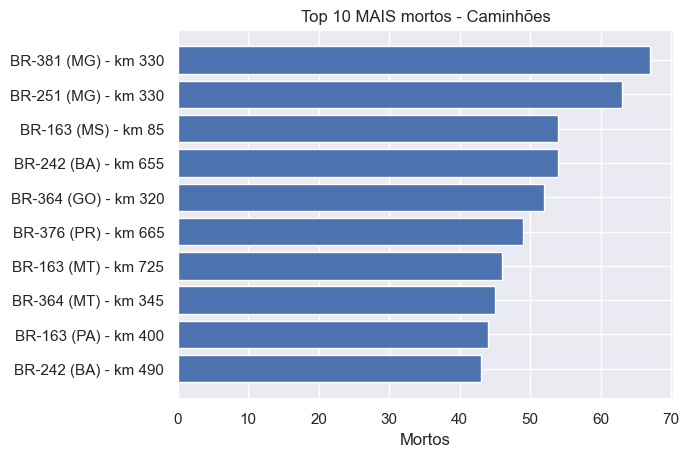

In [33]:
# =============================
# 1️⃣ Filtro de caminhões
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]

# Garantir km_bin
if "km_bin" not in df_map.columns:
    df_map["km"] = pd.to_numeric(df_map["km"], errors="coerce")
    df_map = df_map.dropna(subset=["km"])
    df_map["km_bin"] = ((df_map["km"] // 5) * 5).astype(int)

# Filtrar apenas caminhões
df_tipo = df_map[df_map["tipo_veiculo"].isin(caminhao)].copy()

# =============================
# 2️⃣ Criar métricas
# =============================

df_tipo["impacto_grave"] = (
    df_tipo["mortos"] + df_tipo["feridos_graves"]
)

# =============================
# 3️⃣ Agrupamento por segmento
# =============================

df_seg = df_tipo.groupby(["br", "uf", "km_bin"]).agg(
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    impacto_grave=("impacto_grave", "sum"),
    n_acidentes=("id", "count")
).reset_index()

# Criar nome do segmento
df_seg["segmento"] = (
    "BR-" + df_seg["br"].astype(str) +
    " (" + df_seg["uf"] + ") - km " +
    df_seg["km_bin"].astype(str)
)

# =============================
# 4️⃣ TOP 10 MAIS MORTOS
# =============================

top_mortos = df_seg.sort_values("total_mortos", ascending=False).head(10)

plt.figure()
plt.barh(top_mortos["segmento"], top_mortos["total_mortos"])
plt.title("Top 10 MAIS mortos - Caminhões")
plt.xlabel("Mortos")
plt.gca().invert_yaxis()
plt.show()




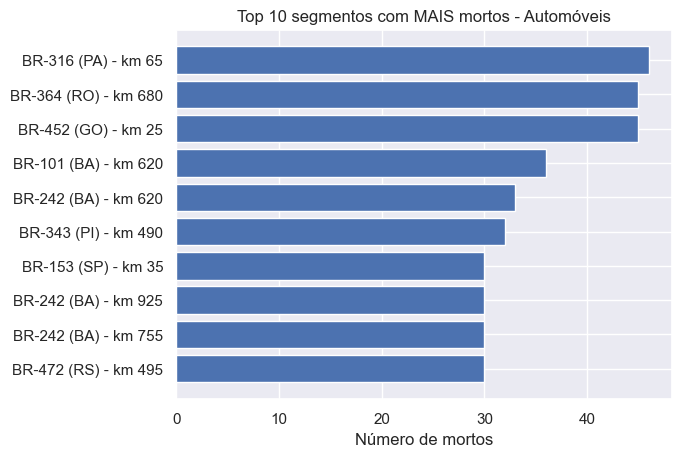

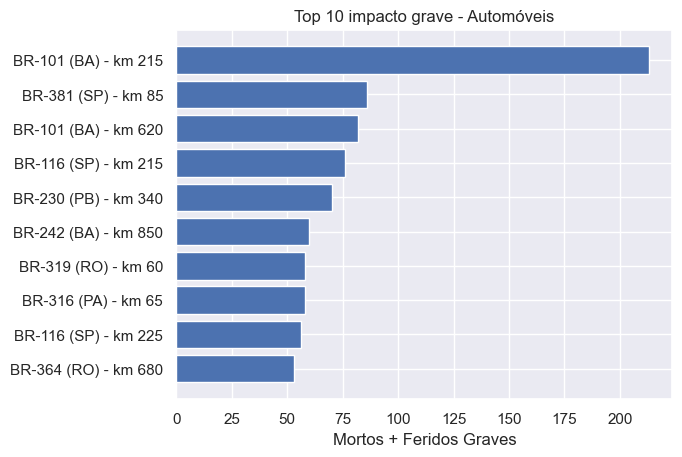

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 🚗 Classe de veículo
# =============================

carros_leves = ["Automóvel"]

# =============================
# 🔥 Garantir km_bin
# =============================

if "km_bin" not in df_map.columns:
    df_map["km"] = pd.to_numeric(df_map["km"], errors="coerce")
    df_map = df_map.dropna(subset=["km"])
    df_map["km_bin"] = ((df_map["km"] // 5) * 5).astype(int)

# =============================
# 1️⃣ Filtrar AUTOMÓVEIS
# =============================

df_auto = df_map[
    df_map["tipo_veiculo"].isin(carros_leves)
].copy()

# =============================
# 2️⃣ Criar métricas
# =============================

df_auto["impacto_grave"] = (
    df_auto["mortos"] + df_auto["feridos_graves"]
)

# =============================
# 3️⃣ Agrupar por segmento
# =============================

df_segmento_auto = df_auto.groupby(
    ["br", "uf", "km_bin"]
).agg(
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    impacto_grave=("impacto_grave", "sum"),
    n_acidentes=("impacto_grave", "count")
).reset_index()

# =============================
# Criar nome do segmento
# =============================

df_segmento_auto["segmento"] = (
    "BR-" + df_segmento_auto["br"].astype(str) +
    " (" + df_segmento_auto["uf"] + ") - km " +
    df_segmento_auto["km_bin"].astype(str)
)

# =============================
# 4️⃣ TOP 10 MAIS MORTOS
# =============================

top_mortos = df_segmento_auto.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()
plt.barh(top_mortos["segmento"], top_mortos["total_mortos"])
plt.xlabel("Número de mortos")
plt.title("Top 10 segmentos com MAIS mortos - Automóveis")
plt.gca().invert_yaxis()
plt.show()

# =============================
# 5️⃣ TOP 10 IMPACTO GRAVE
# =============================

top_impacto = df_segmento_auto.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()
plt.barh(top_impacto["segmento"], top_impacto["impacto_grave"])
plt.xlabel("Mortos + Feridos Graves")
plt.title("Top 10 impacto grave - Automóveis")
plt.gca().invert_yaxis()
plt.show()


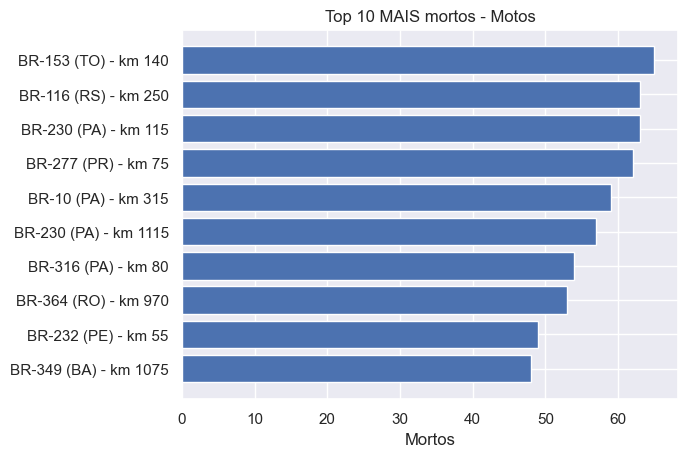

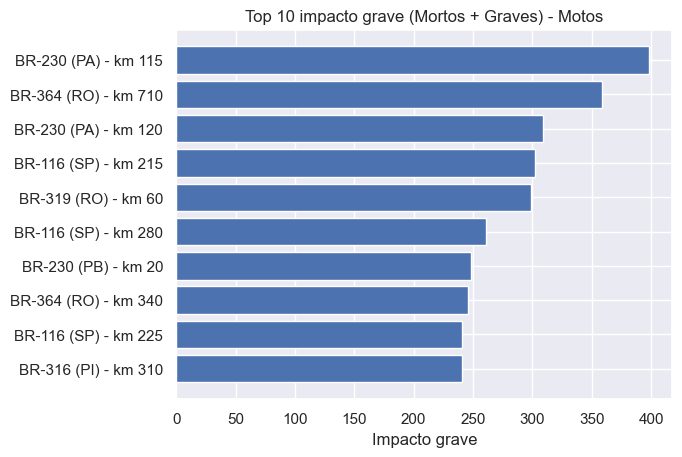

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 🏍️ Classe de veículo
# =============================

motos = ["Motocicleta", "Motoneta"]

# =============================
# 🔥 Garantir km_bin
# =============================

if "km_bin" not in df_map.columns:
    df_map["km"] = pd.to_numeric(df_map["km"], errors="coerce")
    df_map = df_map.dropna(subset=["km"])
    df_map["km_bin"] = ((df_map["km"] // 5) * 5).astype(int)

# =============================
# 1️⃣ Filtrar MOTOS
# =============================

df_tipo = df_map[
    df_map["tipo_veiculo"].isin(motos)
].copy()

# =============================
# 2️⃣ Criar métricas
# =============================

df_tipo["impacto_grave"] = (
    df_tipo["mortos"] + df_tipo["feridos_graves"]
)

# =============================
# 3️⃣ Agrupar por segmento
# =============================

df_seg = df_tipo.groupby(["br", "uf", "km_bin"]).agg(
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    impacto_grave=("impacto_grave", "sum"),
    n_acidentes=("impacto_grave", "count")
).reset_index()

# =============================
# Criar nome do segmento
# =============================

df_seg["segmento"] = (
    "BR-" + df_seg["br"].astype(str) +
    " (" + df_seg["uf"] + ") - km " +
    df_seg["km_bin"].astype(str)
)

# =============================
# 🔴 4️⃣ TOP 10 MAIS MORTOS
# =============================

top_mortos = df_seg.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()
plt.barh(top_mortos["segmento"], top_mortos["total_mortos"])
plt.title("Top 10 MAIS mortos - Motos")
plt.xlabel("Mortos")
plt.gca().invert_yaxis()
plt.show()

# =============================
# ⚠️ 5️⃣ TOP 10 IMPACTO GRAVE
# =============================

top_impacto = df_seg.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()
plt.barh(top_impacto["segmento"], top_impacto["impacto_grave"])
plt.title("Top 10 impacto grave (Mortos + Graves) - Motos")
plt.xlabel("Impacto grave")
plt.gca().invert_yaxis()
plt.show()



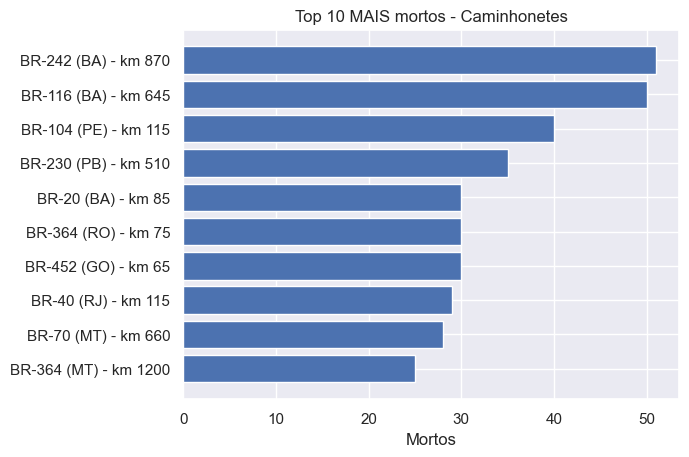

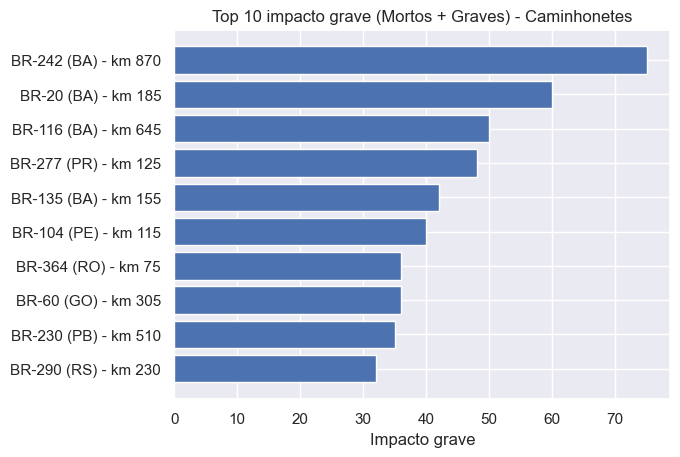

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 🚙 Classe de veículo
# =============================

caminhonetes = ["Caminhonete", "Camioneta", "Utilitário"]

# =============================
# 🔥 Garantir km_bin
# =============================

if "km_bin" not in df_map.columns:
    df_map["km"] = pd.to_numeric(df_map["km"], errors="coerce")
    df_map = df_map.dropna(subset=["km"])
    df_map["km_bin"] = ((df_map["km"] // 5) * 5).astype(int)

# =============================
# 1️⃣ Filtrar CAMINHONETES
# =============================

df_tipo = df_map[
    df_map["tipo_veiculo"].isin(caminhonetes)
].copy()

# =============================
# 2️⃣ Criar métricas
# =============================

df_tipo["impacto_grave"] = (
    df_tipo["mortos"] + df_tipo["feridos_graves"]
)

# =============================
# 3️⃣ Agrupar por segmento
# =============================

df_seg = df_tipo.groupby(["br", "uf", "km_bin"]).agg(
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    impacto_grave=("impacto_grave", "sum"),
    n_acidentes=("impacto_grave", "count")
).reset_index()

# =============================
# Criar nome do segmento
# =============================

df_seg["segmento"] = (
    "BR-" + df_seg["br"].astype(str) +
    " (" + df_seg["uf"] + ") - km " +
    df_seg["km_bin"].astype(str)
)

# =============================
# 🔴 4️⃣ TOP 10 MAIS MORTOS
# =============================

top_mortos = df_seg.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()
plt.barh(top_mortos["segmento"], top_mortos["total_mortos"])
plt.title("Top 10 MAIS mortos - Caminhonetes")
plt.xlabel("Mortos")
plt.gca().invert_yaxis()
plt.show()

# =============================
# ⚠️ 5️⃣ TOP 10 IMPACTO GRAVE
# =============================

top_impacto = df_seg.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()
plt.barh(top_impacto["segmento"], top_impacto["impacto_grave"])
plt.title("Top 10 impacto grave (Mortos + Graves) - Caminhonetes")
plt.xlabel("Impacto grave")
plt.gca().invert_yaxis()
plt.show()



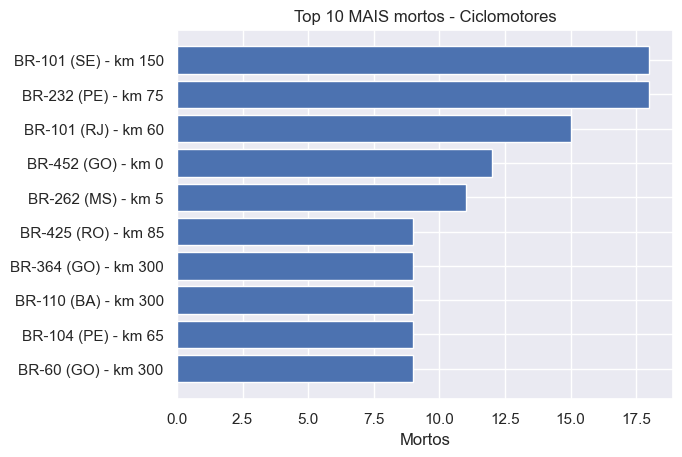

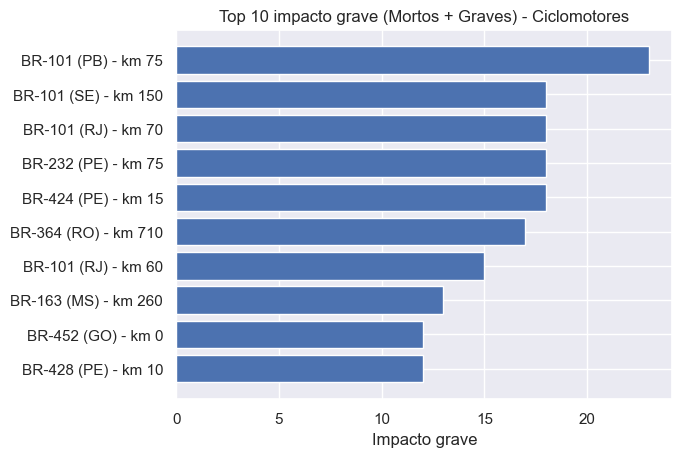

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 🛵 Classe de veículo
# =============================

ciclomotores = ["Ciclomotor", "Triciclo", "Quadriciclo"]

# =============================
# 🔥 Garantir km_bin
# =============================

if "km_bin" not in df_map.columns:
    df_map["km"] = pd.to_numeric(df_map["km"], errors="coerce")
    df_map = df_map.dropna(subset=["km"])
    df_map["km_bin"] = ((df_map["km"] // 5) * 5).astype(int)

# =============================
# 1️⃣ Filtrar CICLOMOTORES
# =============================

df_tipo = df_map[
    df_map["tipo_veiculo"].isin(ciclomotores)
].copy()

# =============================
# 2️⃣ Criar métricas
# =============================

df_tipo["impacto_grave"] = (
    df_tipo["mortos"] + df_tipo["feridos_graves"]
)

# =============================
# 3️⃣ Agrupar por segmento
# =============================

df_seg = df_tipo.groupby(["br", "uf", "km_bin"]).agg(
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    impacto_grave=("impacto_grave", "sum"),
    n_acidentes=("impacto_grave", "count")
).reset_index()

# =============================
# Criar nome do segmento
# =============================

df_seg["segmento"] = (
    "BR-" + df_seg["br"].astype(str) +
    " (" + df_seg["uf"] + ") - km " +
    df_seg["km_bin"].astype(str)
)

# =============================
# 🔴 4️⃣ TOP 10 MAIS MORTOS
# =============================

top_mortos = df_seg.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()
plt.barh(top_mortos["segmento"], top_mortos["total_mortos"])
plt.title("Top 10 MAIS mortos - Ciclomotores")
plt.xlabel("Mortos")
plt.gca().invert_yaxis()
plt.show()

# =============================
# ⚠️ 5️⃣ TOP 10 IMPACTO GRAVE
# =============================

top_impacto = df_seg.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()
plt.barh(top_impacto["segmento"], top_impacto["impacto_grave"])
plt.title("Top 10 impacto grave (Mortos + Graves) - Ciclomotores")
plt.xlabel("Impacto grave")
plt.gca().invert_yaxis()
plt.show()



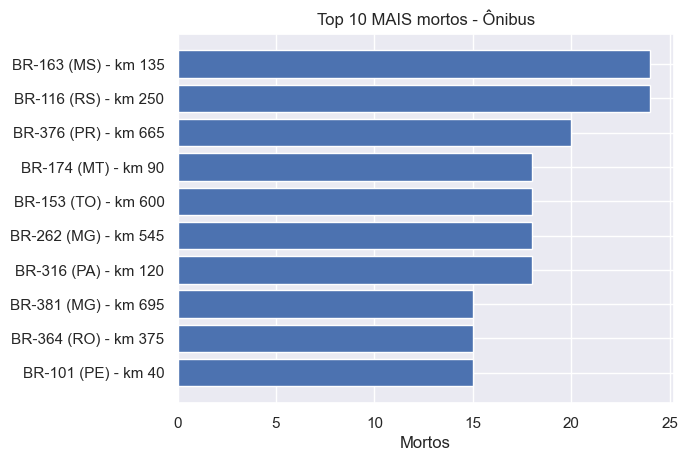

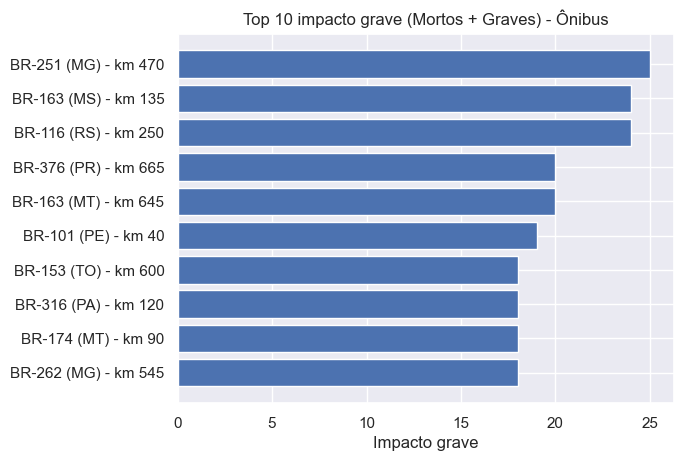

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 🚌 Classe de veículo
# =============================

onibus = ["Ônibus", "Micro-ônibus"]

# =============================
# 🔥 Garantir km_bin
# =============================

if "km_bin" not in df_map.columns:
    df_map["km"] = pd.to_numeric(df_map["km"], errors="coerce")
    df_map = df_map.dropna(subset=["km"])
    df_map["km_bin"] = ((df_map["km"] // 5) * 5).astype(int)

# =============================
# 1️⃣ Filtrar ÔNIBUS
# =============================

df_tipo = df_map[
    df_map["tipo_veiculo"].isin(onibus)
].copy()

# =============================
# 2️⃣ Criar métricas
# =============================

df_tipo["impacto_grave"] = (
    df_tipo["mortos"] + df_tipo["feridos_graves"]
)

# =============================
# 3️⃣ Agrupar por segmento
# =============================

df_seg = df_tipo.groupby(["br", "uf", "km_bin"]).agg(
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    impacto_grave=("impacto_grave", "sum"),
    n_acidentes=("impacto_grave", "count")  # ⚠️ se tiver ID, usar nunique!
).reset_index()

# =============================
# Criar nome do segmento
# =============================

df_seg["segmento"] = (
    "BR-" + df_seg["br"].astype(str) +
    " (" + df_seg["uf"] + ") - km " +
    df_seg["km_bin"].astype(str)
)

# =============================
# 🔴 4️⃣ TOP 10 MAIS MORTOS
# =============================

top_mortos = df_seg.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()
plt.barh(top_mortos["segmento"], top_mortos["total_mortos"])
plt.title("Top 10 MAIS mortos - Ônibus")
plt.xlabel("Mortos")
plt.gca().invert_yaxis()
plt.show()

# =============================
# ⚠️ 5️⃣ TOP 10 IMPACTO GRAVE
# =============================

top_impacto = df_seg.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()
plt.barh(top_impacto["segmento"], top_impacto["impacto_grave"])
plt.title("Top 10 impacto grave (Mortos + Graves) - Ônibus")
plt.xlabel("Impacto grave")
plt.gca().invert_yaxis()
plt.show()

